# Setup

In [1]:
import dataclasses

import jax

from openpi.models import model as _model
from openpi.policies import droid_policy
from openpi.policies import policy_config as _policy_config
from openpi.shared import download
from openpi.training import config as _config
from openpi.training import data_loader as _data_loader
from openpi_client import image_tools

import Pyro5.api
import numpy as np

## Loading a model

In [ ]:
# config = _config.get_config("pi0_fast_droid")
# checkpoint_dir = download.maybe_download("gs://openpi-assets/checkpoints/pi0_fast_droid")
# print(f"Loading model from {checkpoint_dir}")

In [2]:
# CHANGE 'action' to 'actions' IN NORM_STATS.JSON FIRST
%env CUDA_VISIBLE_DEVICES=0,1
# load the model
config = _config.get_config("pi0_RPM_low_mem_finetune")
checkpoint_dir = '/data/checkpoints/pi0_RPM_low_mem_finetune/LoRA_2GPU_pickblueblockblackbowl/7000'
# checkpoint_dir = '/home/liao0241/openpi/checkpoints/pi0_RPM_low_mem_finetune/LoRA_2GPU_pickblueblockblackbowl_presumablycorrectednormstats/7000'

# Create a trained policy.
policy = _policy_config.create_trained_policy(config, checkpoint_dir)

env: CUDA_VISIBLE_DEVICES=0,1


In [ ]:
# # First state in a trajectory
# np.array(
#     [-3.018277883529663, -2.4735472202301025, -1.4247097969055176, -1.420408844947815, 0.47022080421447754, 0.31647270917892456]
#     + [-0.6982309818267822, 0.13667820394039154, 0.06255360692739487]
#     + [-1.4045917987823486, -1.7060638666152954, -1.2871901988983154]
#     + [3]  # gripper
# )

In [ ]:
# delete current policy to free up memory, then load a new one
# del policy

In [ ]:
# Run inference on a dummy example. This example corresponds to observations produced by the DROID runtime.
# example = droid_policy.make_droid_example()
# result = policy.infer(example)
# print("Actions shape:", result["actions"].shape)

## Initialize and test cameras

In [3]:
import pyrealsense2 as rs
import numpy as np
import cv2
import matplotlib.pyplot as plt

class RealSenseCamera:
    def __init__(self, serial_number, width=640, height=480, fps=30):
        self.serial = serial_number
        self.pipeline = rs.pipeline()
        self.config = rs.config()
        self.config.enable_device(self.serial)
        self.config.enable_stream(rs.stream.color, width, height, rs.format.bgr8, fps)
        self.pipeline.start(self.config)

    def get_image(self):
        frames = self.pipeline.wait_for_frames()
        color_frame = frames.get_color_frame()
        if not color_frame:
            return None

        bgr = np.asanyarray(color_frame.get_data())
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return rgb

    def release(self):
        self.pipeline.stop()


# initialize cameras
serial_head = "f1380660"
serial_wrist = "128422270284"
cam_head = RealSenseCamera(serial_head)
cam_wrist = RealSenseCamera(serial_wrist)

In [ ]:
# from openpi_client import image_tools

# img_head = image_tools.resize_with_pad(
#                         cam_head.get_image(), 224, 224
#                     )

# img_wrist = image_tools.resize_with_pad(
#                         cam_wrist.get_image(), 224, 224
#                     )


# # combine the two images
# combined = np.hstack((img_head, img_wrist))  # shape (224, 224*2, 3)

# # display the combined image
# plt.figure(figsize=(8, 4))
# plt.imshow(combined)
# plt.title("Head + Wrist(RGB 224x224)")
# plt.axis('off')
# plt.show()

In [7]:
cam_head.release()
cam_wrist.release()

# Optional: Compare ground truth actions with predicted actions

In [44]:
# Get ground truth state and actions for comparison from a trajectory (.pkl file)
import pickle

def get_pickle_values(pickle_file_path, keys=None):
    """Extract and display the contents of a trajectory and store them."""
    try:
        with open(pickle_file_path, 'rb') as f:
            data = pickle.load(f)
        # Initialize a dict to store keys and their values
        value_dict = {}
        # If it's a dictionary, display the keys and values
        if isinstance(data, dict):
            # print(data['meta'])
            for key, value in data.items():
                # print(type(value))
                if isinstance(value, list):
                    # print(f"- {key}: List of length {len(value)}")
                    for timestep in value:
                        for k in keys:
                            if k in timestep:
                                value_dict.setdefault(k, []).append(timestep[k])

                        # print(timestep.keys())
                        # print(timestep['joint_positions'])
                        # print(timestep['eef_pose']['position'], timestep['eef_pose']['orientation_rpy'])
                        # print(timestep['gripper_state'])
                        # action_list.append((timestep['spark_command_angles'], timestep['spark_command_gripper']))
    except Exception as e:
        print(f"Error opening {pickle_file_path}: {e}")

    return value_dict

GT_path = '/data/shared_data/real_world_data/pickblueblock_blackbowl/traj_1758307262.pkl'
GT_dict = get_pickle_values(GT_path, keys=['joint_positions', 'eef_pose', 'gripper_state', 'spark_command_angles', 'spark_command_gripper'])

In [ ]:
# Get ground truth actions
GT_actions = []
for i, j in zip(GT_dict['spark_command_angles'], GT_dict['spark_command_gripper']):
    GT_actions.append([*i, j])

In [10]:
# Get all the frames from trajectory videos
import cv2
import numpy as np
# Assuming 'image_tools' is available in your environment for resizing
# import image_tools 

# observation.image_scene and observation.image_wrist videos
video_scene = '/home/liao0241/.cache/huggingface/lerobot/iamandrewliao/pickblueblock_blackbowl/videos/chunk-000/observation.image_scene/episode_000000.mp4'
video_wrist = '/home/liao0241/.cache/huggingface/lerobot/iamandrewliao/pickblueblock_blackbowl/videos/chunk-000/observation.image_wrist/episode_000000.mp4'

# Extract all the frames from both videos
frames_scene = []
frames_wrist = []

# Initialize video capture objects
cap_head = cv2.VideoCapture(video_scene)
cap_wrist = cv2.VideoCapture(video_wrist)

# Basic check to ensure videos opened
if not cap_head.isOpened():
    raise IOError(f"Error opening head camera video: {video_scene}")
if not cap_wrist.isOpened():
    raise IOError(f"Error opening wrist camera video: {video_wrist}")

# Set up a loop to read frames until both videos have ended
# We use two separate return flags (ret_head, ret_wrist) to control the process.
ret_head = True
ret_wrist = True

while ret_head or ret_wrist:
    # Read the next frame from the videos
    # Note: We must read even if one video has ended, in case the other hasn't.
    ret_head, frame_head = cap_head.read()
    ret_wrist, frame_wrist = cap_wrist.read()

    # --- Frame Processing and Storage ---

    # Process the scene (head) camera frame if it was successfully read
    if ret_head:
        # Convert from BGR (OpenCV default) to RGB
        frame_head_rgb = cv2.cvtColor(frame_head, cv2.COLOR_BGR2RGB)
        frames_scene.append(frame_head_rgb)

    # Process the wrist camera frame if it was successfully read
    if ret_wrist:
        # Convert from BGR (OpenCV default) to RGB
        frame_wrist_rgb = cv2.cvtColor(frame_wrist, cv2.COLOR_BGR2RGB)
        frames_wrist.append(frame_wrist_rgb)

    # Termination check: Exit the loop when neither video successfully returns a frame
    if not ret_head and not ret_wrist:
        break

# IMPORTANT: Release the video capture objects
cap_head.release()
cap_wrist.release()

print(f"Successfully extracted {len(frames_scene)} frames from the scene video.")
print(f"Successfully extracted {len(frames_wrist)} frames from the wrist video.")

Successfully extracted 173 frames from the scene video.
Successfully extracted 173 frames from the wrist video.


In [ ]:
# Get action predictions for trajectory
pred_actions = []
for i in range(len(frames_scene)):
    observation = {
        'observation.image_scene': frames_scene[i],
        'observation.image_wrist': frames_wrist[i],
        'observation.state': np.concatenate(
            (GT_dict['joint_positions'][i], GT_dict['eef_pose'][i]['position'], GT_dict['eef_pose'][i]['orientation_rpy'], [GT_dict['gripper_state'][i]])
            ),
        "prompt": "pick the blue block and place it in the black bowl"
    }
    result = policy.infer(observation)  # to get just one action, I changed 'action_horizon' in pi0_config.py to 1
    pred_actions.append(result['actions'])

In [120]:
import numpy as np

def clip_action(action_array, max_norm):
    """
    Clips a single action vector based on its L2 norm.
    
    Args:
        action_array (np.ndarray): The predicted action, expected shape (1, 7).
        max_norm (float): The maximum allowed L2 norm.
        
    Returns:
        np.ndarray: The clipped or original action array.
    """
    # Fix 1: Corrected numpy linear algebra module name
    # Fix 2: Flatten the (1, 7) array to a 7-element vector for norm calculation
    # We use .flatten()[0] to access the first (and only) row if it's (1, 7)
    action_vector = action_array.flatten()
    
    # Calculate the L2 norm (Euclidean distance)
    norm = np.linalg.norm(action_vector)
    
    # Check if the norm exceeds the maximum
    if norm > max_norm:
        # Scale down the vector to the max_norm while preserving its direction
        # Note: We must return the result in the original shape (1, 7)
        clipped_vector = (action_vector / norm) * max_norm
        clipped_action_array = clipped_vector.reshape(1, -1)
        
        # print(f"Action clipped. Original norm: {norm:.4f}, New norm: {max_norm:.4f}")
        return clipped_action_array, 1
    else:
        # print(f"Action not clipped. Norm: {norm:.4f}")
        return action_array, 0
    

# Choose an appropriate max norm based on your robot's capabilities. 
MAX_NORM = 4

clipped_pred_actions = []
clipped = 0

for pred_action in pred_actions:
    clipped_action, s = clip_action(pred_action, MAX_NORM)
    clipped += s
    clipped_pred_actions.append(clipped_action)

print(f"Number of actions clipped: {clipped}")

Number of actions clipped: 173


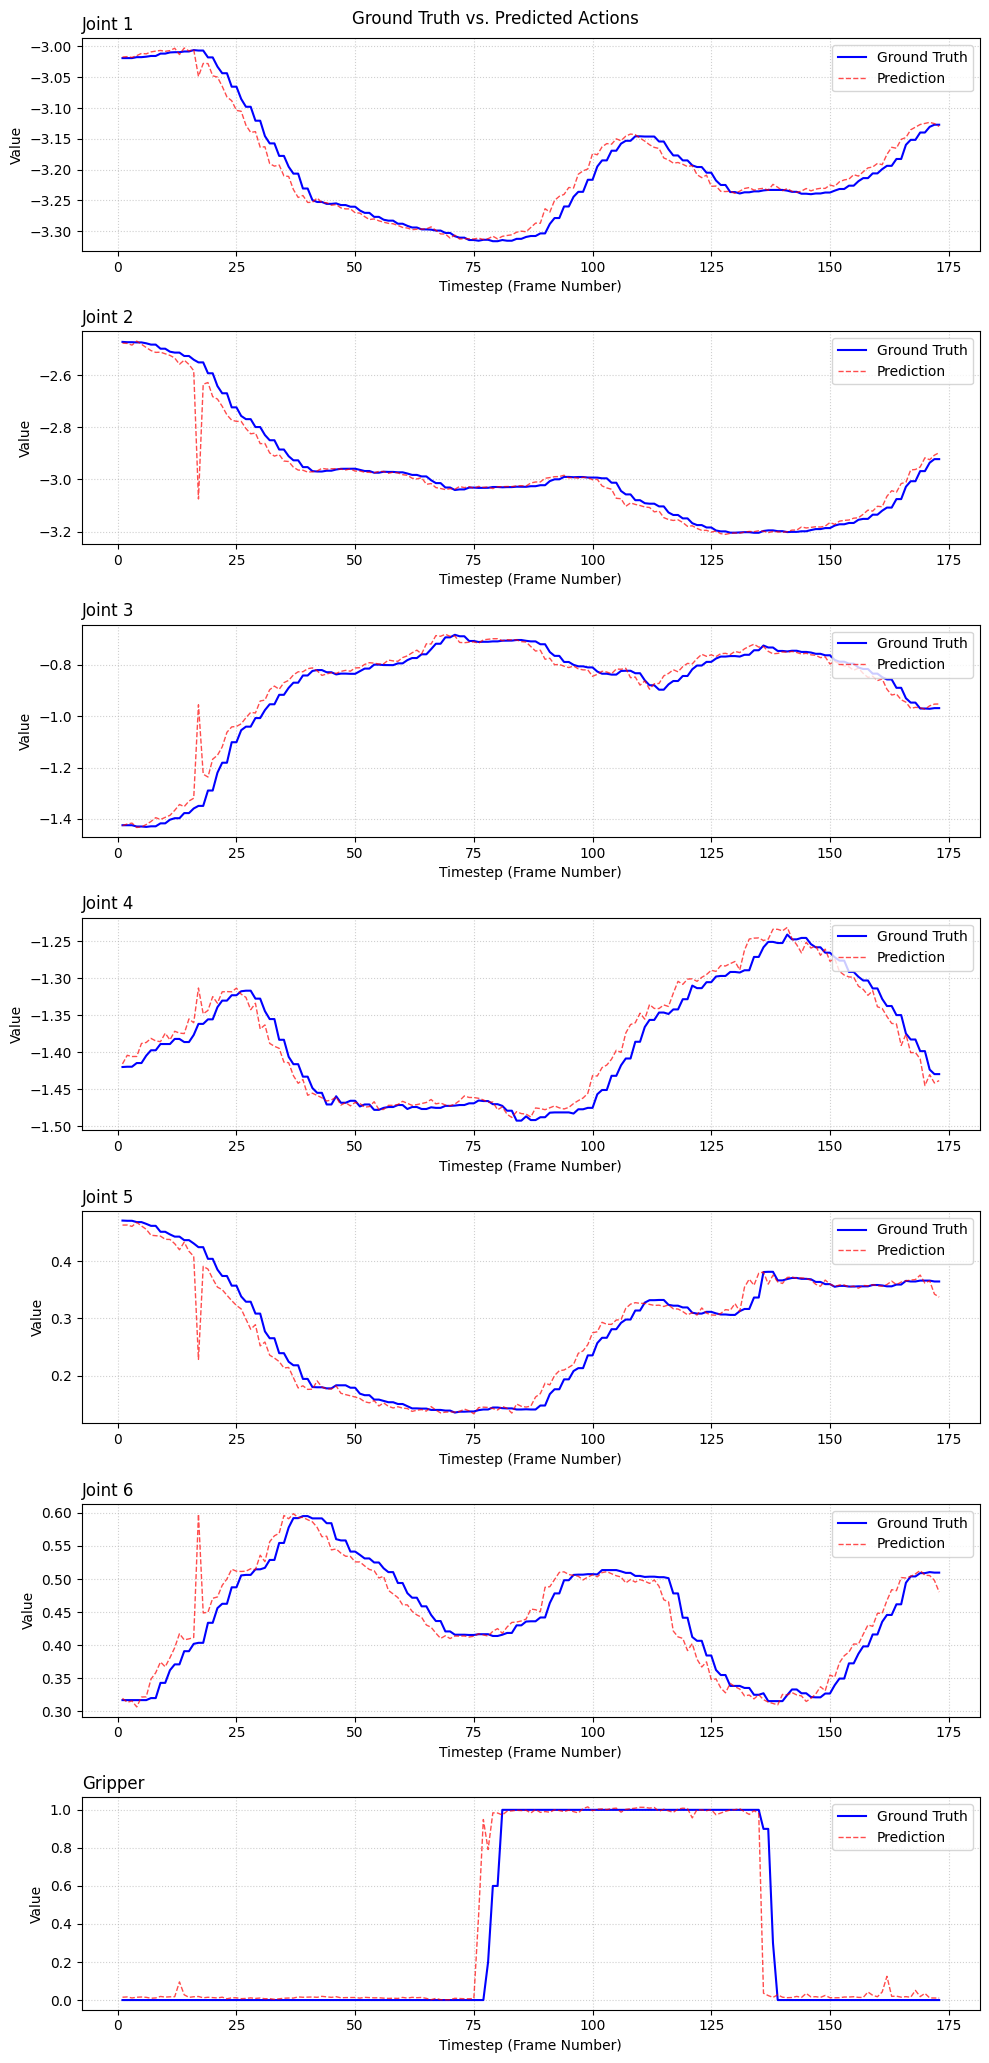

In [122]:
import matplotlib.pyplot as plt

labels = [f"Joint {i+1}" for i in range(6)] + ["Gripper"]
DOF = 7
timesteps = np.arange(1, len(GT_actions)+1)
PREDICTED_ACTIONS = pred_actions

fig, axes = plt.subplots(
    nrows=DOF, 
    ncols=1, 
    figsize=(10, 3 * DOF), # Adjust height for all subplots
)
fig.suptitle('Ground Truth vs. Predicted Actions')

for i in range(DOF):
    ax = axes[i]
    ax.plot(
        timesteps, 
        [a_t[i] for a_t in GT_actions], 
        label='Ground Truth', color='blue', linestyle='-', linewidth=1.5
    )
    ax.plot(
        timesteps, 
        [a_t[0][i] for a_t in PREDICTED_ACTIONS], 
        label='Prediction', 
        color='red', linestyle='--', linewidth=1.0, alpha=0.7
    )
    
    # Set titles and labels
    ax.set_title(labels[i], loc='left')
    ax.set_ylabel('Value')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right')
    ax.set_xlabel('Timestep (Frame Number)')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()    


In [ ]:
# # action clipping
# def clip_action(action, max_norm):
#     norm = np.lingalg.norm(action)
#     if norm > max_norm:
#         # Scale down the vector to the max_norm while preserving its direction
#         clipped_action = (action / norm) * max_norm
#         print(f"Action clipped. Original norm: {norm:.4f}, New norm: {max_norm:.4f}")
#         return clipped_action
#     else:
#         # If the norm is within the threshold, return the original action
#         print(f"Action not clipped. Norm: {norm:.4f}")
#         return action

# Actual deployment

In [7]:
# vla_policy_client
import Pyro5.api
import numpy as np
import time
from openpi_client import image_tools

ns = Pyro5.api.locate_ns()  # Locate the name server
uri = ns.lookup("pi0_controller")  # Use the name server to look up the URI
# uri = "PYRO:obj_a3bc7b8f8b4f4a3f9622d9f7ef83ac41@10.131.235.100:9090"
controller = Pyro5.api.Proxy(uri)

# prompt
prompt = "pick up the blue block and place it into the black bowl"  # <-- change prompt

MAX_STEPS = 50000  # maximum number of steps to run
MAX_NORM = 0.8  # change as appropriate
video_buffer = []  # buffer to store video frames

# # dummy action
action = np.zeros((50,7), dtype=np.float32)
action_list = action.tolist()  # convert to list for sending

for step in range(MAX_STEPS):
    start = time.time()
    print(f"\n=== Step {step} ===")
    # Send action to controller to execute
    data_to_send = {
        "type": "action",
        "data": action_list,
        "step": step
    }
    start1 = time.time()
    print(f"Sending data to controller: {data_to_send}")
    obs = controller.step(data_to_send) # returns {'robot state':...,'step':...}
    end1 = time.time()
    print(f"Controller step took {end1 - start1:.2f} seconds")

    # Create an observation to do the next inference
    img_left = image_tools.resize_with_pad(
                            cam_head.get_image(), 224, 224
                        )
    img_wrist = image_tools.resize_with_pad(
                            cam_wrist.get_image(), 224, 224
                        )
    # save the images
    combined = np.hstack([img_left, img_wrist])
    video_buffer.append(combined)

    observation = {
        "observation.image_scene": img_left,
        # "observation/exterior_image_1_left": np.zeros_like(img_left),  # dummy image for left
        "observation.image_wrist": img_wrist,
        # "observation/wrist_image_left": np.zeros_like(img_wrist),  # dummy image for wrist
        "observation.state": np.array(obs["robot_state"], dtype=np.float32),
        # "observation/gripper_position": np.array([obs["gripper_state"]], dtype=np.float32),  
        # "observation/joint_position": np.zeros_like(obs["robot_state"], dtype=np.float32),
        # "observation/gripper_position": np.zeros_like([obs["gripper_state"]], dtype=np.float32),  
        "prompt": prompt,
    }

    # Inference
    result = policy.infer(observation)

    curr_action = result["actions"]
    action_list = curr_action.tolist()

    # # Optional: Clip actions if norm of delta is too high
    # delta_action = curr_action - observation['observation.state']
    # final_action = clip_action(delta_action, MAX_NORM)
    # action_list = final_action.tolist()
    
    end2 = time.time()
    print(f"Inference took {end2 - end1:.2f} seconds")
    print(f"Action at step {step}:", action_list[0])
    end = time.time()
    print(f"Step {step} took {end - start:.2f} seconds")


=== Step 0 ===
Sending data to controller: {'type': 'action', 'data': [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.

ConnectionClosedError: receiving: not enough data